### 1. Завантаження даних

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштовуємо чистий мінімалістичний стиль для всіх графіків
sns.set_theme(style="whitegrid", palette="muted")

# Завантажуємо вбудований датасет Титанік
df = sns.load_dataset('titanic')

print("Дані успішно завантажено! Перші 5 рядків:")
display(df.head())

print("\nКількість пропусків ДО очищення по кожній колонці:")
# Виводимо тільки ті колонки, де є хоча б один пропуск
print(df.isnull().sum()[df.isnull().sum() > 0])

Дані успішно завантажено! Перші 5 рядків:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Кількість пропусків ДО очищення по кожній колонці:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64


### 2. Здійснити Data Cleaning

In [5]:


# 1. Колонка 'deck' (палуба) має занадто багато пропусків (понад 600), тому ми її видаляємо повністю
df = df.drop(columns=['deck'])

# 2. 'age' (вік) має пропуски - заповнюємо їх середнім арифметичним віком пасажирів
df['age'] = df['age'].fillna(df['age'].mean())

# 3. 'embarked' та 'embark_town' (порт посадки) - заповнюємо найчастішим значенням (модою)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

print("Кількість пропусків ПІСЛЯ очищення (має бути 0):")
print(df.isnull().sum().sum())

print("\nГотовий чистий датасет для побудови графіків:")
display(df.head())

Кількість пропусків ПІСЛЯ очищення (має бути 0):
0

Готовий чистий датасет для побудови графіків:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


### 3. Побудувати графіки залежності одного integer/real атрибута від іншого (lineplot, scatter etc).

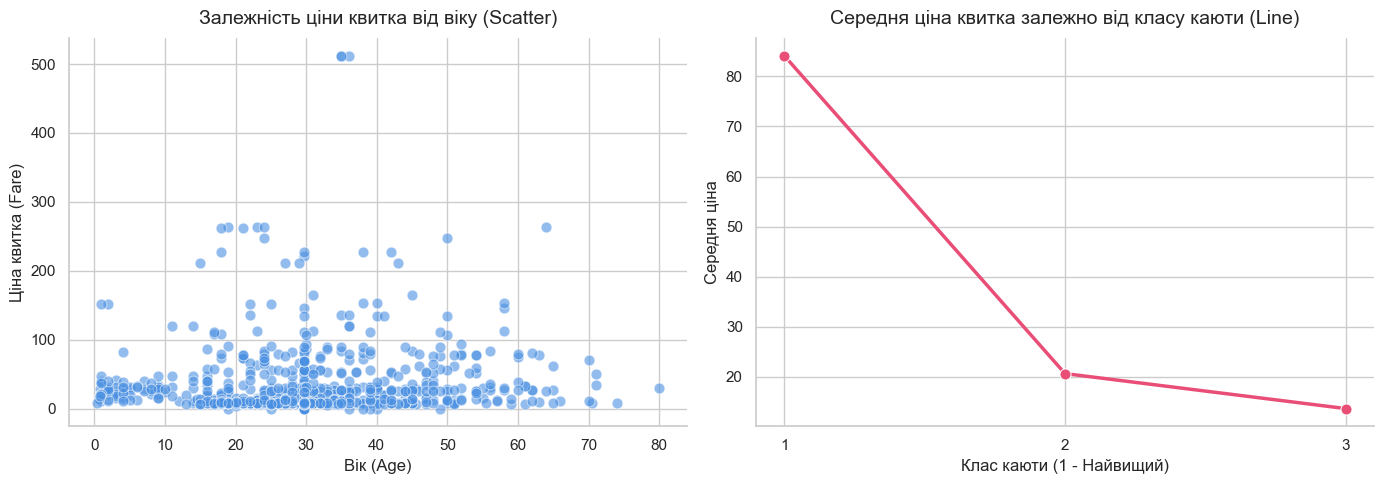

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))

# 1. Scatter plot (Точковий графік) - Вік та Ціна квитка
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='age', y='fare', alpha=0.6, color='#4A90E2', s=60)
plt.title('Залежність ціни квитка від віку (Scatter)', fontsize=14, pad=10)
plt.xlabel('Вік (Age)')
plt.ylabel('Ціна квитка (Fare)')
sns.despine()

# 2. Line plot (Лінійний графік) - Середня ціна квитка по класах
plt.subplot(1, 2, 2)
# Групуємо дані, щоб лінія була чіткою
class_fare = df.groupby('pclass')['fare'].mean().reset_index()
sns.lineplot(data=class_fare, x='pclass', y='fare', marker='o', color='#E94E77', linewidth=2.5, markersize=8)
plt.title('Середня ціна квитка залежно від класу каюти (Line)', fontsize=14, pad=10)
plt.xlabel('Клас каюти (1 - Найвищий)')
plt.ylabel('Середня ціна')
plt.xticks([1, 2, 3]) # Класів лише 3
sns.despine()

plt.tight_layout()
plt.show()

### 4. Побудувати гістограму по одному з атрибутів, що буде показувати на кількість елементів, що знаходяться у 5 діапазонах, які ви задасте.

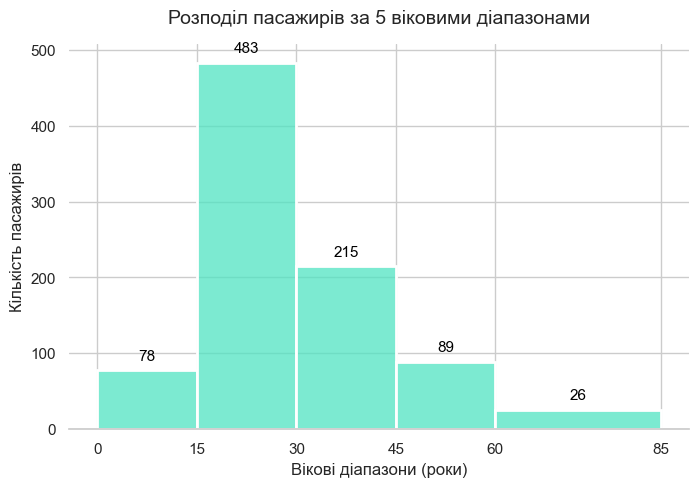

In [7]:
plt.figure(figsize=(8, 5))

# Задаємо 5 чітких діапазонів віку: 0-15 (Діти), 15-30 (Молодь), 30-45 (Дорослі), 45-60 (Старші), 60-80+ (Літні)
custom_bins = [0, 15, 30, 45, 60, 85]

# Будуємо гістограму
ax = sns.histplot(data=df, x='age', bins=custom_bins, color='#50E3C2', edgecolor='white', linewidth=2)

plt.title('Розподіл пасажирів за 5 віковими діапазонами', fontsize=14, pad=15)
plt.xlabel('Вікові діапазони (роки)')
plt.ylabel('Кількість пасажирів')
plt.xticks(custom_bins)
sns.despine(left=True)

# Додаємо цифри над кожним стовпчиком для наочності
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.show()

### 5. Збудувати графіки, використовуючи приклади, наведені у https://medium.com/data-science/the-art-of-effective-visualization-of-multi-dimensional-data-6c7202990c57 

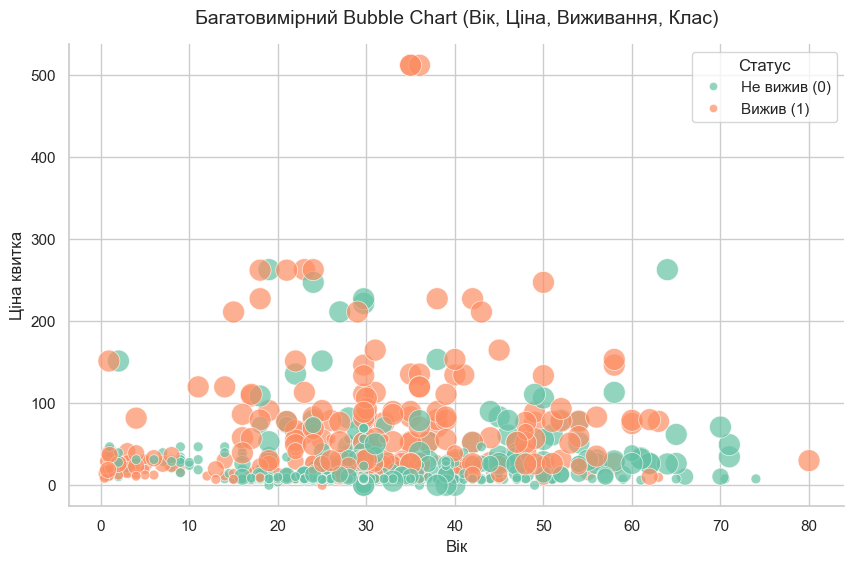

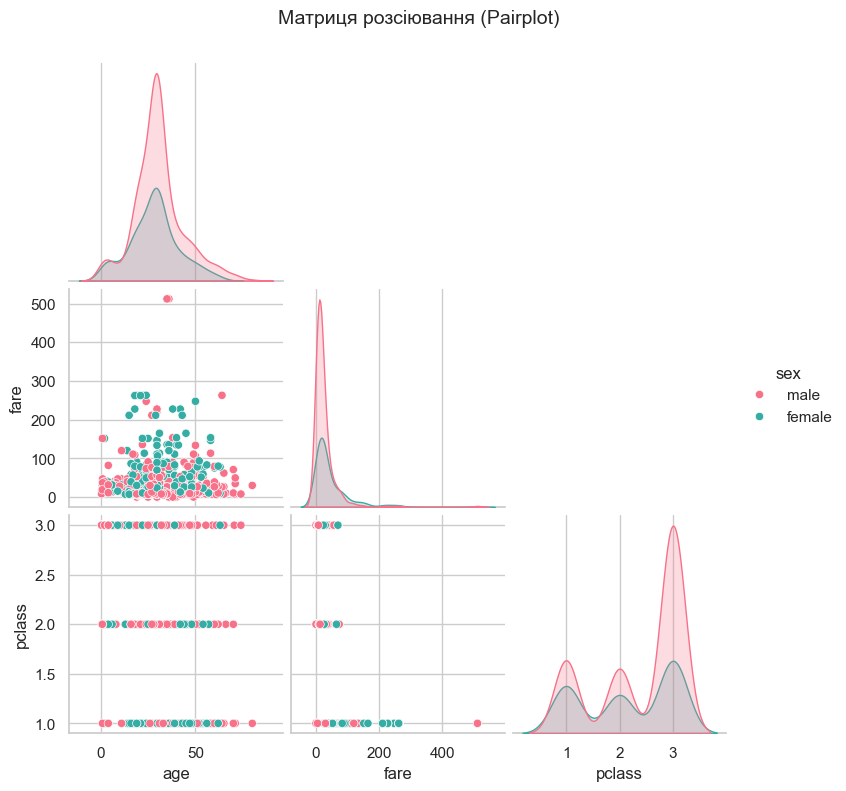

In [8]:
# 1. Bubble Chart (4 виміри: x=вік, y=ціна, колір=виживання, розмір точки=клас)
plt.figure(figsize=(10, 6))
# Інвертуємо класи для розміру, щоб 1 клас був найбільшим кружечком
bubble_size = (4 - df['pclass']) * 50 

sns.scatterplot(data=df, x='age', y='fare', hue='survived', size=bubble_size, sizes=(50, 250), 
                palette='Set2', alpha=0.7, legend='brief')

plt.title('Багатовимірний Bubble Chart (Вік, Ціна, Виживання, Клас)', fontsize=14, pad=15)
plt.xlabel('Вік')
plt.ylabel('Ціна квитка')
# Налаштовуємо легенду виживання (1 - Вижив, 0 - Ні)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[1:3], ['Не вижив (0)', 'Вижив (1)'], title='Статус', loc='upper right')
sns.despine()
plt.show()

print("\n")

# 2. Pairplot (Матриця розсіювання для кількох числових змінних одночасно)
# Беремо найважливіші змінні і розфарбовуємо по статі
multi_vars = ['age', 'fare', 'pclass']
sns.pairplot(df[multi_vars + ['sex']], hue='sex', palette='husl', corner=True, height=2.5)
plt.suptitle('Матриця розсіювання (Pairplot)', y=1.05, fontsize=14)
plt.show()

### 6. Побудувати інші графіки, що покажуть корисну інформацію про датасет. 


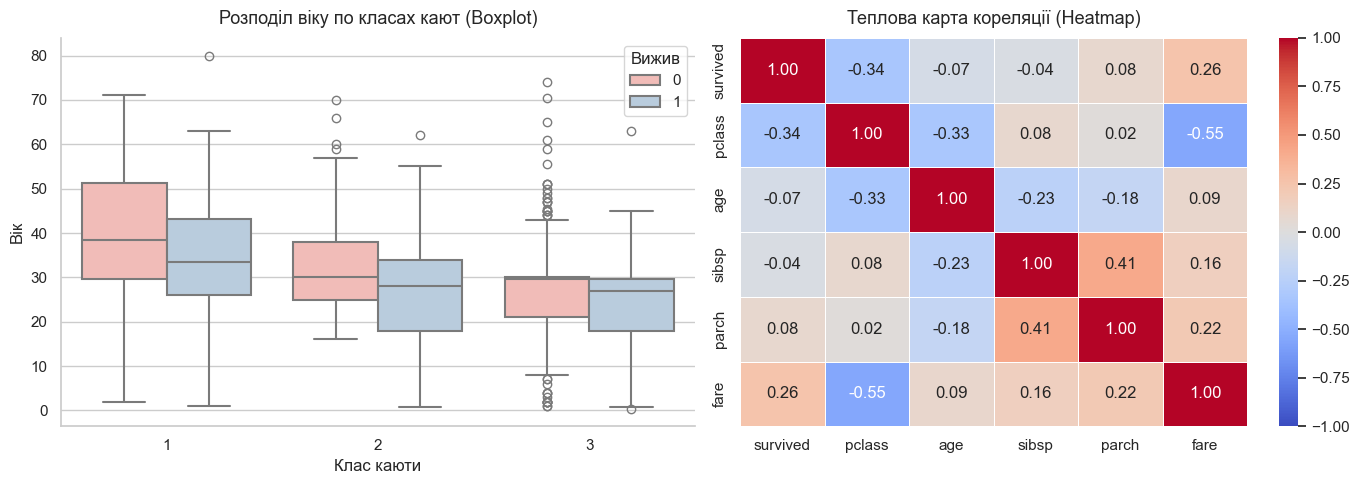

In [9]:
plt.figure(figsize=(14, 5))

# 1. Boxplot (Ящик з вусами) - показує розподіл віку в різних класах та аномалії (викиди)
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='pclass', y='age', hue='survived', palette='Pastel1', linewidth=1.5)
plt.title('Розподіл віку по класах кают (Boxplot)', fontsize=13, pad=10)
plt.xlabel('Клас каюти')
plt.ylabel('Вік')
plt.legend(title='Вижив')
sns.despine()

# 2. Теплова карта кореляції (Heatmap) - показує, як усі числові дані залежать одне від одного
plt.subplot(1, 2, 2)
# Обираємо тільки числові колонки, щоб уникнути помилок
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()

# Малюємо стильну матрицю
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Теплова карта кореляції (Heatmap)', fontsize=13, pad=10)

plt.tight_layout()
plt.show()